In [1]:
# 02_model_midcal.ipynb — CELL 1: SETUP (load everything)

import pandas as pd
import numpy as np
from pathlib import Path

# ---- paths (you already confirmed these exist) ----
kelp_path = Path("../../1_DATA/processed/midcal/kelp_timeseries_midcal_bbox.csv")
sst_feat_path = Path("../../1_DATA/processed/midcal/oisst_features_midcal_quarterly.csv")

# ---- load kelp ----
df_kelp = pd.read_csv(kelp_path, index_col=0, parse_dates=True).sort_index()

# coverage==0 means missing imagery, not real zero kelp
df_kelp.loc[df_kelp["coverage"] == 0, "kelp_area"] = np.nan

# smooth AFTER fixing missing (4 quarters ≈ 1 year)
df_kelp["kelp_smooth"] = df_kelp["kelp_area"].rolling(4, center=True, min_periods=1).mean()

# ---- load SST features (already aligned to kelp timestamps) ----
df_sst = pd.read_csv(sst_feat_path, index_col=0, parse_dates=True).sort_index()

print("Kelp rows:", len(df_kelp), "| range:", df_kelp.index.min(), "to", df_kelp.index.max())
print("SST  rows:", len(df_sst),  "| range:", df_sst.index.min(),  "to", df_sst.index.max())
print("Kelp cols:", list(df_kelp.columns))
print("SST  cols:", list(df_sst.columns))

df_kelp.head()

Kelp rows: 167 | range: 1984-02-15 00:00:00 to 2025-08-15 00:00:00
SST  rows: 167 | range: 1984-02-15 00:00:00 to 2025-08-15 00:00:00
Kelp cols: ['kelp_area', 'coverage', 'kelp_smooth', 'coverage_frac']
SST  cols: ['sst_q_mean', 'sstanom_q_mean', 'sstanom_q_max', 'sstanom_pos_sum', 'sstanom_exceed_months', 'sstanom_q_mean_lag1', 'sstanom_pos_sum_lag1', 'sstanom_q_max_lag1']


,kelp_area,coverage,kelp_smooth,coverage_frac
1984-02-15,NaN,0,114310.0,0.000000
1984-05-15,114310.0,4731,155341.0,0.972856
1984-08-15,196372.0,4840,105917.0,0.995270
1984-11-15,7069.0,4850,85294.5,0.997327
1985-02-15,23427.0,943,102484.0,0.193913


In [2]:
# 02_model_midcal.ipynb — CELL 2: CLEAN + MERGE (make the analysis table)

# merge
df = df_kelp.join(df_sst, how="inner").sort_index()

# coverage quality filter (removes sketchy kelp quarters)
cov_thresh = 0.8 * df["coverage"].max()
df = df[df["coverage"] >= cov_thresh].copy()

# drop rows missing key predictors (will drop 2021 SST gap automatically)
need = ["kelp_smooth", "sstanom_q_mean", "sstanom_q_max"]
for c in need:
    if c not in df.columns:
        raise KeyError(f"Missing column '{c}' in merged table. Available: {list(df.columns)}")

df = df.dropna(subset=need)

print("Merged+clean rows:", len(df))
print("Range:", df.index.min(), "to", df.index.max())
print("Coverage threshold:", cov_thresh)

df.head()

Merged+clean rows: 157
Range: 1984-05-15 00:00:00 to 2025-08-15 00:00:00
Coverage threshold: 3890.4


,kelp_area,coverage,kelp_smooth,coverage_frac,sst_q_mean,sstanom_q_mean,sstanom_q_max,sstanom_pos_sum,sstanom_exceed_months,sstanom_q_mean_lag1,sstanom_pos_sum_lag1,sstanom_q_max_lag1
1984-05-15,114310.0,4731,155341.000000,0.972856,12.322297,-0.563491,-0.464906,0.000000,1,0.523896,1.571688,0.816057
1984-08-15,196372.0,4840,105917.000000,0.995270,15.775856,0.665889,0.922719,1.997667,1,-0.563491,0.000000,-0.464906
1984-11-15,7069.0,4850,85294.500000,0.997327,13.939277,-0.103716,0.176351,0.176351,1,0.665889,1.997667,0.922719
1985-11-15,166688.0,4726,116891.333333,0.971828,13.138452,-0.904540,-0.054317,0.000000,1,0.233475,0.905934,0.889905
1986-02-15,918.0,4798,96289.000000,0.986634,13.422072,0.916741,1.323946,2.750223,1,-0.904540,0.000000,-0.054317


count    157.000000
mean       0.604758
std        1.831660
min       -2.673427
25%       -0.857519
50%        0.347528
75%        1.830686
max        5.599270
Name: kelp_q_z, dtype: float64


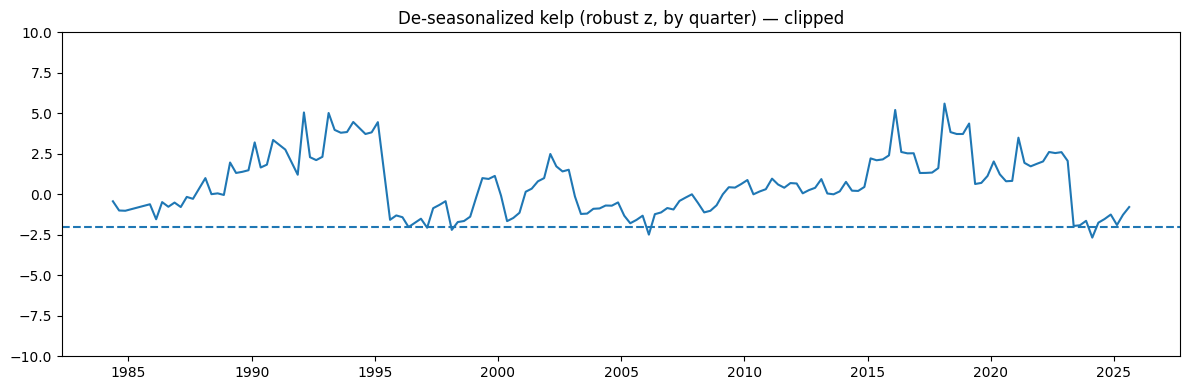

,start,end,n_q,min_z,duration_years
kelp_q_z,,,,,
2,1996-05-15,1996-05-15,1,-2.023036,0.25
4,1997-02-15,1997-02-15,1,-2.063326,0.25
6,1998-02-15,1998-02-15,1,-2.195556,0.25
8,2006-02-15,2006-02-15,1,-2.488991,0.25
10,2024-02-15,2024-02-15,1,-2.673427,0.25


In [3]:
### defining collapse using z
import numpy as np
import matplotlib.pyplot as plt

# use your CLEANED modeling table (after coverage filter + dropna)
df["q"] = df.index.quarter

baseline = df.loc["1984":"2013"]  # pre-Blob baseline, but only clean rows

med = baseline.groupby("q")["kelp_smooth"].median()
mad = baseline.groupby("q")["kelp_smooth"].apply(lambda x: np.median(np.abs(x - np.median(x))) + 1e-9)

df["kelp_q_z"] = (df["kelp_smooth"] - df["q"].map(med)) / df["q"].map(mad)

print(df["kelp_q_z"].describe())

# plot (clip so outliers don't flatten everything)
plt.figure(figsize=(12,4))
plt.plot(df.index, df["kelp_q_z"].clip(-10,10))
plt.axhline(-2, linestyle="--")
plt.ylim(-10, 10)
plt.title("De-seasonalized kelp (robust z, by quarter) — clipped")
plt.tight_layout()
plt.show()

# "doesn't rebound" = sustained low z episodes
low = df["kelp_q_z"] <= -2
seg = (low != low.shift()).cumsum()

episodes = (df[low].groupby(seg)["kelp_q_z"]
            .agg(start=lambda s: s.index.min(),
                 end=lambda s: s.index.max(),
                 n_q="size",
                 min_z="min"))
episodes["duration_years"] = episodes["n_q"] / 4

display(episodes.sort_values("duration_years", ascending=False).head(10))

threshold: -1.5104572349979701
counts: collapse
0    139
1     18
Name: count, dtype: int64


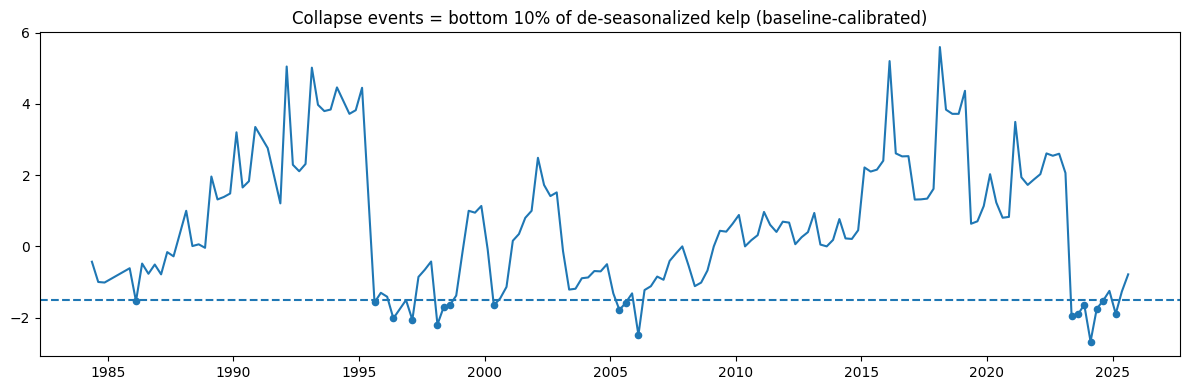

In [4]:
# collapse = unusually low for that quarter (quantile-based, baseline-calibrated)

base = df.loc["1984":"2013", "kelp_q_z"]
thresh = base.quantile(0.10)   # try 0.10 first; later test 0.05

df["collapse"] = (df["kelp_q_z"] <= thresh).astype(int)

print("threshold:", thresh)
print("counts:", df["collapse"].value_counts())

import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(df.index, df["kelp_q_z"])
plt.axhline(thresh, linestyle="--")
plt.scatter(df.index[df["collapse"]==1],
            df.loc[df["collapse"]==1, "kelp_q_z"], s=20)
plt.title("Collapse events = bottom 10% of de-seasonalized kelp (baseline-calibrated)")
plt.tight_layout()
plt.show()

In [5]:
# collapse episodes (runs of consecutive collapse quarters)
low = df["collapse"] == 1
seg = (low != low.shift()).cumsum()

episodes = (df[low].groupby(seg)["kelp_q_z"]
            .agg(start=lambda s: s.index.min(),
                 end=lambda s: s.index.max(),
                 n_q="size",
                 min_z="min"))
episodes["duration_years"] = episodes["n_q"] / 4

display(episodes.sort_values("duration_years", ascending=False).head(15))

,start,end,n_q,min_z,duration_years
collapse,,,,,
18,2023-05-15,2024-08-15,6,-2.673427,1.50
10,1998-02-15,1998-08-15,3,-2.195556,0.75
14,2005-05-15,2005-08-15,2,-1.786369,0.50
2,1986-02-15,1986-02-15,1,-1.540325,0.25
4,1995-08-15,1995-08-15,1,-1.574552,0.25
6,1996-05-15,1996-05-15,1,-2.023036,0.25
8,1997-02-15,1997-02-15,1,-2.063326,0.25
12,2000-05-15,2000-05-15,1,-1.656811,0.25
16,2006-02-15,2006-02-15,1,-2.488991,0.25


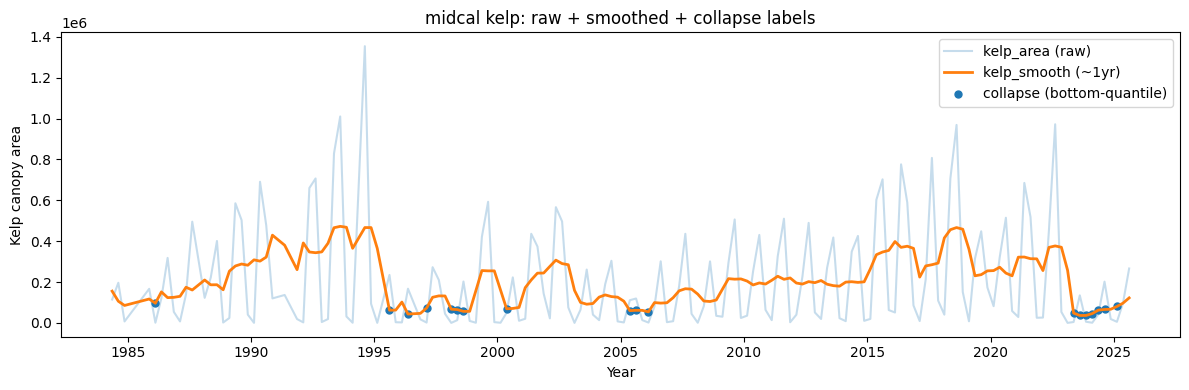

In [6]:
# plot the low thresh holds
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(df.index, df["kelp_area"], alpha=0.25, label="kelp_area (raw)")
plt.plot(df.index, df["kelp_smooth"], linewidth=2, label="kelp_smooth (~1yr)")

if "collapse" in df.columns:
    plt.scatter(df.index[df["collapse"]==1],
                df.loc[df["collapse"]==1, "kelp_smooth"],
                s=25, label="collapse (bottom-quantile)")

plt.title("midcal kelp: raw + smoothed + collapse labels")
plt.xlabel("Year")
plt.ylabel("Kelp canopy area")
plt.legend()
plt.tight_layout()
plt.show()

Suppression params: {'SUP_ROLL': 4, 'SUP_QTAIL': 0.1, 'sup_thresh': -1.3466816820187009}
Suppressed counts: {0: 140, 1: 17}


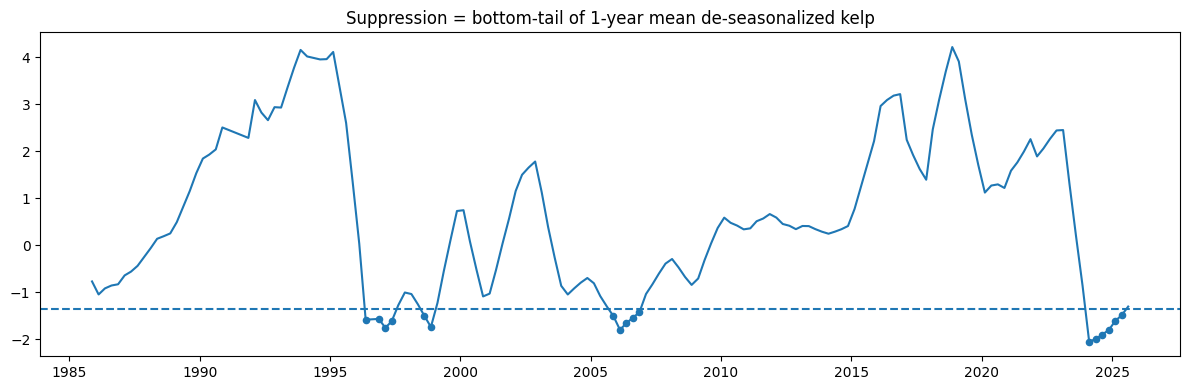

In [7]:
# === SUPPRESSION LABEL (persistent low state) ===
# idea: kelp is "suppressed" if the *1-year mean* of de-seasonalized kelp is in the bottom tail

SUP_ROLL = 4      # 4 quarters = 1 year
SUP_QTAIL = 0.10  # tune later (0.05 / 0.10 / 0.15)
BASE_START, BASE_END = "1984", "2013"

# 1-year rolling mean of kelp_q_z
df["kelp_z_1yr"] = df["kelp_q_z"].rolling(SUP_ROLL, min_periods=SUP_ROLL).mean()

# threshold learned from baseline distribution of the 1-year metric
base_1yr = df.loc[BASE_START:BASE_END, "kelp_z_1yr"].dropna()
sup_thresh = base_1yr.quantile(SUP_QTAIL)

df["suppressed"] = (df["kelp_z_1yr"] <= sup_thresh).astype(int)

print("Suppression params:", {"SUP_ROLL": SUP_ROLL, "SUP_QTAIL": SUP_QTAIL, "sup_thresh": float(sup_thresh)})
print("Suppressed counts:", df["suppressed"].value_counts().to_dict())

import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(df.index, df["kelp_z_1yr"])
plt.axhline(sup_thresh, linestyle="--")
plt.scatter(df.index[df["suppressed"]==1],
            df.loc[df["suppressed"]==1, "kelp_z_1yr"], s=20)
plt.title("Suppression = bottom-tail of 1-year mean de-seasonalized kelp")
plt.tight_layout()
plt.show()

In [10]:
out = df[[
    "kelp_area","kelp_smooth","coverage","coverage_frac",
    "kelp_q_z","kelp_z_1yr","collapse","suppressed",
    "sstanom_q_mean","sstanom_q_max","sstanom_q_mean_lag1"
]].copy()

out.to_csv("../../1_DATA/processed/midcal/midcal_kelp_sst_labeled.csv")
print("saved:", out.shape)

saved: (157, 11)


In [13]:
from pathlib import Path
import matplotlib.pyplot as plt

Path("../../5_FIGURES/midcal/").mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(12,4))

ax.plot(df.index, df["kelp_z_1yr"])
ax.axhline(sup_thresh, linestyle="--")

mask = df["suppressed"] == 1
ax.scatter(df.index[mask], df.loc[mask, "kelp_z_1yr"], s=20)

ax.set_title("Suppression = bottom-tail of 1-year mean de-seasonalized kelp")
fig.tight_layout()

outpath = Path("../../5_FIGURES/midcal_suppression_label.png")
fig.savefig(outpath, dpi=200, bbox_inches="tight")
plt.close(fig)

print("saved to:", outpath.resolve(), "| bytes:", outpath.stat().st_size)

saved to: /Users/tonylin/Documents/kelp_project/5_FIGURES/midcal_suppression_label.png | bytes: 105308


In [15]:
# plot with kelp, suppress, and q z
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# load labeled table
path = "../../1_DATA/processed/midcal_kelp_sst_labeled.csv"
d = pd.read_csv(path, index_col=0, parse_dates=True).sort_index()

# output folder
fig_dir = Path("../../5_FIGURES/midcal")
fig_dir.mkdir(parents=True, exist_ok=True)
outpath = fig_dir / "midcal_kelp_suppression_z_combined.png"

# combined figure (2 panels)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Panel 1: kelp_smooth + suppressed markers
ax1.plot(d.index, d["kelp_smooth"], label="kelp_smooth")
mask = d.get("suppressed", 0).astype(int) == 1
ax1.scatter(d.index[mask], d.loc[mask, "kelp_smooth"], s=25, label="suppressed")
ax1.set_ylabel("Kelp canopy area")
ax1.set_title("midcal kelp + suppression + de-seasonalized z")
ax1.legend()

# Panel 2: kelp_q_z (+ threshold if you saved it; otherwise show baseline-ish reference)
ax2.plot(d.index, d["kelp_q_z"], label="kelp_q_z (de-seasonalized)")
ax2.axhline(d["kelp_q_z"].quantile(0.10), linestyle="--", label="10th pct (all years)")
ax2.set_ylabel("Robust z (MAD units)")
ax2.set_xlabel("Year")
ax2.legend()

fig.tight_layout()
fig.savefig(outpath, dpi=200, bbox_inches="tight")
plt.close(fig)

print("saved:", outpath.resolve(), "bytes:", outpath.stat().st_size)

saved: /Users/tonylin/Documents/kelp_project/5_FIGURES/midcal/midcal_kelp_suppression_z_combined.png bytes: 240008


In [16]:
#plot kelp smooth
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

d = pd.read_csv("../../1_DATA/processed/midcal_kelp_sst_labeled.csv",
                index_col=0, parse_dates=True).sort_index()

fig_dir = Path("../../5_FIGURES/midcal")
fig_dir.mkdir(parents=True, exist_ok=True)
outpath = fig_dir / "midcal_kelp_smooth.png"

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(d.index, d["kelp_smooth"])
ax.set_title("midcal kelp_smooth (~1 year rolling mean)")
ax.set_xlabel("Year")
ax.set_ylabel("Kelp canopy area")
fig.tight_layout()

fig.savefig(outpath, dpi=200, bbox_inches="tight")
plt.close(fig)

print("saved:", outpath.resolve(), "bytes:", outpath.stat().st_size)

saved: /Users/tonylin/Documents/kelp_project/5_FIGURES/midcal/midcal_kelp_smooth.png bytes: 122395
